![Alt Text](path/to/image.png)

### **Task 1: Exploratory Data Analytics \[1 pt]**

#### (a) Data Loading & Feature Vector Construction \[0.5 pt]

* Load the dataset.
* Construct a feature vector for each article.
* Report:

  * Number of articles.
  * Number of extracted features.
* Show 5 example articles with their extracted features using a dataframe.

#### (b) Term Frequency Analysis \[0.5 pt]

* Report the following three plots:

  1. Top-50 term frequency distribution across the entire dataset.
  2. Term frequency distribution for each class of articles.
  3. Class distribution plot.

---

### **Task 2: Classification Models Learning \[4 pts]**

#### (a) **NB (Naive Bayes Classifier)** \[2 pts]

* Train a Naive Bayes classifier using all article features.
* Report:

  1. Top-20 most identifiable words most likely to occur in the articles across two classes using NB classifier.
  2. Top-20 words that maximize the ratio:

     $$
     \frac{P(X_w = 1 | Y = y)}{P(X_w = 1 | Y \ne y)}
     $$
* Briefly explain which list of words better describes the two classes and why.

#### (b) **kNN (k-Nearest Neighbors Classifier)** \[1 pt]

* Train a kNN classifier on the training dataset.
* Report:

  * Surface plot of your kNN with chosen hyperparameters $k$ and distance metric.
  * Explanation of the impact of $k$ and the distance metric on the decision boundary.


In [1]:
import pandas as pd
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report

from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder


# **Task 1: Exploratory Data Analytics \[1 pt]** (`train.csv` and `test.csv`)

### (a) Data Loading & Feature Vector Construction \[0.5 pt]

* Load the dataset.


In [2]:
# Load the datasets
train_df = pd.read_csv("/kaggle/input/a3-data/train.csv")
test_df = pd.read_csv("/kaggle/input/a3-data/test.csv")


#### Both train.csv and test.csv successfully loaded

In [3]:
train_df.head()

,ArticleId,Text,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


In [4]:
test_df.head()

,ArticleId,Text,Category
0,1821,johnny denise lose passport johnny vaughan den...,entertainment
1,522,bt offers free net phone calls bt offering cus...,tech
2,636,power people says hp digital revolution focuse...,tech
3,170,stars gear bafta ceremony film stars across gl...,entertainment
4,85,controversial film tops festival controversial...,entertainment


In [5]:

# Display basic information for verification
print("num_articles")
train_df.shape[0]


num_articles


428

In [6]:
print("num_features")
train_df.shape[1]

num_features


3

In [7]:
print("column_names")
train_df.columns.tolist()

column_names


['ArticleId', 'Text', 'Category']

In [8]:
print("sample_articles")
train_df.head(5)

sample_articles


,ArticleId,Text,Category
0,1976,lifestyle governs mobile choice faster better ...,tech
1,1797,french honour director parker british film dir...,entertainment
2,1866,fockers fuel festive film chart comedy meet fo...,entertainment
3,1153,housewives lift channel 4 ratings debut us tel...,entertainment
4,342,u2 desire number one u2 three prestigious gram...,entertainment


In [9]:
print("num_articles") 
test_df.shape[0]


num_articles


106

In [10]:
print("num_features") 
test_df.shape[1]


num_features


3

In [11]:
print("column_names") 
test_df.columns.tolist()


column_names


['ArticleId', 'Text', 'Category']

In [12]:
print("sample_articles")
test_df.head(5)


sample_articles


,ArticleId,Text,Category
0,1821,johnny denise lose passport johnny vaughan den...,entertainment
1,522,bt offers free net phone calls bt offering cus...,tech
2,636,power people says hp digital revolution focuse...,tech
3,170,stars gear bafta ceremony film stars across gl...,entertainment
4,85,controversial film tops festival controversial...,entertainment


## Construct a feature vector for each article.


##  CountVectorizer
**Bag of Words (BoW)** model.

It converts a collection of text documents into a matrix of **token counts**, where:

* Each column represents a unique word (token) from the corpus.
* Each row represents a document (article).
* The values are the **frequency** of the word in that document.



In [13]:
# Initialize CountVectorizer
count_vectorizer = CountVectorizer()

# Fit and transform the training text data
count_features = count_vectorizer.fit_transform(train_df['Text'])

# Convert to DataFrame for display
count_df = pd.DataFrame(count_features.toarray(), columns=count_vectorizer.get_feature_names_out())

# Show top 5 example articles with extracted features
count_df.head()


,00,000,000th,001st,0051,007,0100,0130,028,05,...,zola,zombie,zombies,zone,zonealarm,zones,zoom,zooms,zooropa,zorro
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


* Report:

  * Number of articles.
  * Number of extracted features.
* Show 5 example articles with their extracted features using a dataframe.

In [14]:

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the training text data
tfidf_features = tfidf_vectorizer.fit_transform(train_df['Text'])

# Convert to DataFrame for display
tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Show top 5 example articles with extracted features
tfidf_df.head()


,00,000,000th,001st,0051,007,0100,0130,028,05,...,zola,zombie,zombies,zone,zonealarm,zones,zoom,zooms,zooropa,zorro
0,0.0,0.020115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
1,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
2,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
3,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
4,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.054551,0.0



## Task(b) Term Frequency Analysis \[0.5 pt]

### 1. Top-50 term frequency distribution across the entire dataset

In [15]:
# CountVectorizer for raw term frequency
vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(train_df["Text"])
feature_names = vectorizer.get_feature_names_out()

In [16]:
# Total term frequencies across all documents
term_frequencies = np.array(X_counts.sum(axis=0)).flatten()
term_freq_dict = dict(zip(feature_names, term_frequencies))


In [17]:
# Top-50 term frequencies
top_50 = Counter(term_freq_dict).most_common(50)
top_50_terms, top_50_counts = zip(*top_50)

### Plot 1: Top-50 term frequency distribution across the entire dataset

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


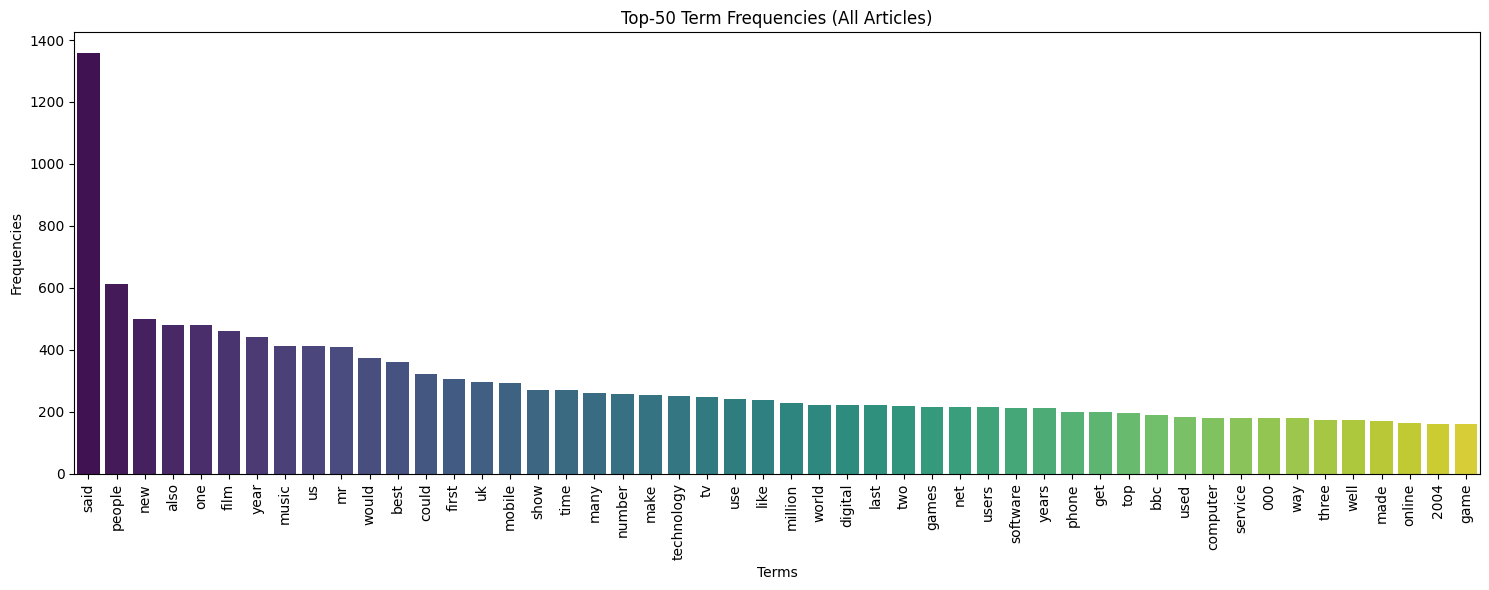

In [18]:
plt.figure(figsize=(15, 6))
sns.barplot(x=list(top_50_terms), y=list(top_50_counts), palette="viridis")
plt.xticks(rotation=90)
plt.title("Top-50 Term Frequencies (All Articles)")
plt.xlabel("Terms")
plt.ylabel("Frequencies")
plt.tight_layout()
plt.show()



### 2. Term frequency distribution for each class of articles.
  

### Plot 2: Term frequency distribution for each class of articles

In [19]:
# Get the class labels
classes = train_df['Category'].unique()

# Initialize dictionary to hold term frequencies per class
class_term_freq = {}

In [20]:
# Compute term frequencies separately for each class
for category in classes:
    texts = train_df[train_df['Category'] == category]['Text']
    X_class_counts = vectorizer.transform(texts)
    term_frequencies_class = np.array(X_class_counts.sum(axis=0)).flatten()
    class_term_freq[category] = dict(zip(feature_names, term_frequencies_class))

# Select top 10 terms for each class
top_terms_per_class = {
    cls: Counter(freq_dict).most_common(10) for cls, freq_dict in class_term_freq.items()
}

### Plotting top 10 terms per class


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


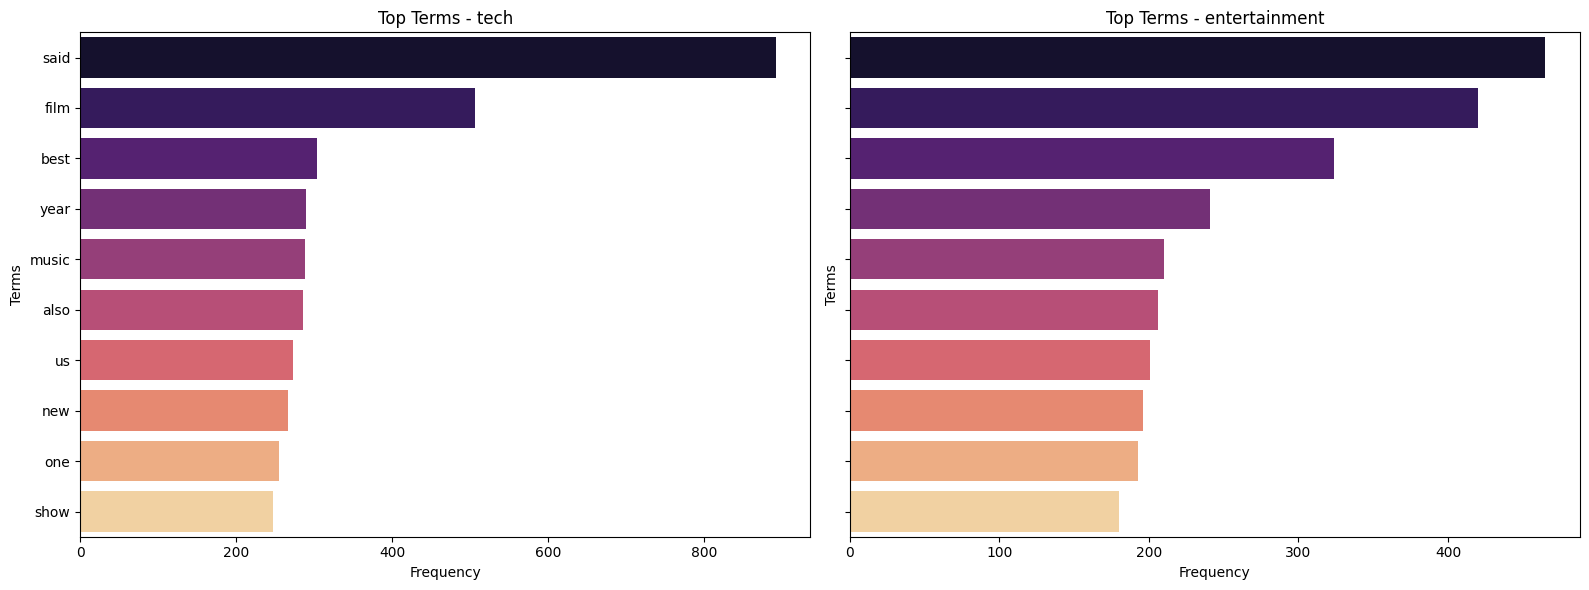

In [21]:

fig, axes = plt.subplots(1, len(classes), figsize=(16, 6), sharey=True)

for idx, cls in enumerate(classes):
    terms, counts = zip(*top_terms_per_class[cls])
    sns.barplot(x=list(counts), y=list(terms), ax=axes[idx], palette="magma")
    axes[idx].set_title(f"Top Terms - {cls}")
    axes[idx].set_xlabel("Frequency")
    axes[idx].set_ylabel("Terms")

plt.tight_layout()
plt.show()



### Plot 3: Class distribution plot

In [22]:
# Count number of articles per class
class_counts = train_df['Category'].value_counts()


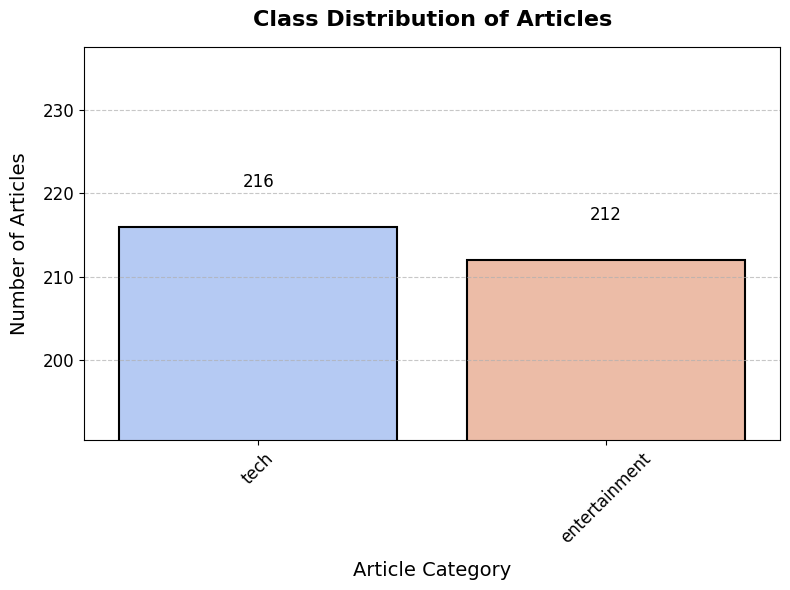

In [23]:
plt.figure(figsize=(8, 6))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette="coolwarm",
    edgecolor="black",
    linewidth=1.5
)

# Add data labels on top of the bars
for i, v in enumerate(class_counts.values):
    plt.text(i, v + max(class_counts.values)*0.02, str(v), ha='center', va='bottom', fontsize=12, color='black')

# Enhance readability
plt.title("Class Distribution of Articles", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Article Category", fontsize=14, labelpad=10)
plt.ylabel("Number of Articles", fontsize=14, labelpad=10)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add a grid for easier comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Set y-axis limits to not start from zero
y_min = min(class_counts.values) - (max(class_counts.values) * 0.1)
y_min = max(0, y_min)  # Ensure it doesn't go below zero if that's undesired
plt.ylim(y_min, max(class_counts.values) * 1.1)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


### Task 1(b): Term Frequency 

####  **1. Top-50 Term Frequency Distribution (All Articles)**

* A bar chart displaying the 50 most frequent terms across the entire dataset.
* Terms are sorted in descending order by frequency.
* Gives a clear view of the most common language used in all articles.

---

####  **2. Term Frequency per Class**

* Separate horizontal bar charts for each class:

  * **tech**
  * **entertainment**
* Shows the top 10 most frequent words in each category.
* Helps identify class-specific vocabulary.

---

####  **3. Class Distribution Plot**

* A bar chart of the number of articles per category.
* Confirms whether the dataset is balanced or imbalanced between classes.



##  **Task 2: Classification Models Learning \[4 pts]**

#### (a) **NB (Naive Bayes Classifier)** \[2 pts]

* Train a Naive Bayes classifier using all article features.
* Report:

  1. Top-20 most identifiable words most likely to occur in the articles across two classes using NB classifier.
  2. Top-20 words that maximize the ratio:

     $$
     \frac{P(X_w = 1 | Y = y)}{P(X_w = 1 | Y \ne y)}
     $$
* Briefly explain which list of words better describes the two classes and why.

### 1. **Train a kNN classifier**

* Use `TfidfVectorizer` for better handling of text for distance-based models like kNN.
* Reduce dimensions (e.g., via PCA or TruncatedSVD) to **2D** so we can plot a decision surface.

#### 2. **Report Surface Plot**

* Visualize decision boundaries using a mesh grid and color regions by predicted class.

#### 3. **Explain the effect of**:

* Varying **`k`** (e.g., small vs large `k`)
* Changing **distance metric** (e.g., Euclidean vs Cosine)



In [24]:

# Vectorize text using binary CountVectorizer for word presence
count_vectorizer = CountVectorizer(binary=True)
X = count_vectorizer.fit_transform(train_df["Text"])
y = train_df["Category"]

# Optional: Split dataset (not strictly required for this analysis task)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Naive Bayes classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Get feature names and log probabilities
feature_names = count_vectorizer.get_feature_names_out()
log_probs = nb_model.feature_log_prob_

#  Top 20 words most likely to occur in each class
top_20_words_per_class = {}
for i, class_label in enumerate(nb_model.classes_):
    top_indices = np.argsort(log_probs[i])[::-1][:20]
    top_words = [(feature_names[j], np.exp(log_probs[i][j])) for j in top_indices]
    top_20_words_per_class[class_label] = top_words

#  Top 20 words maximizing the likelihood ratio P(Xw=1|Y=y) / P(Xw=1|Y≠y)
top_ratio_words = {}
for i, class_label in enumerate(nb_model.classes_):
    this_class_prob = np.exp(log_probs[i])
    other_class_prob = np.exp(log_probs[1 - i])
    ratio = this_class_prob / (other_class_prob + 1e-9)  # avoid divide by zero
    top_indices = np.argsort(ratio)[::-1][:20]
    top_words = [(feature_names[j], ratio[j]) for j in top_indices]
    top_ratio_words[class_label] = top_words

# Results
top_20_words_per_class, top_ratio_words


({'entertainment': [('said', 0.0034992023876910445),
   ('year', 0.0027530489373745696),
   ('also', 0.002470025214840736),
   ('one', 0.002264189780270676),
   ('film', 0.0021355426336643873),
   ('us', 0.0021098132043431295),
   ('new', 0.0020583543457006128),
   ('first', 0.002032624916379356),
   ('last', 0.0019039777697730685),
   ('show', 0.0016466834765604904),
   ('best', 0.0016466834765604904),
   ('time', 0.0015952246179179758),
   ('star', 0.001569495188596718),
   ('tv', 0.0015437657592754599),
   ('including', 0.0014923069006329446),
   ('two', 0.0014923069006329446),
   ('years', 0.0014408480419904302),
   ('three', 0.0013893891833479145),
   ('would', 0.0013636597540266574),
   ('music', 0.0013379303247053986)],
  'tech': [('said', 0.0031889678948502486),
   ('people', 0.0026287438052143954),
   ('also', 0.0023917259211376865),
   ('new', 0.002348631760396467),
   ('one', 0.002240896358543418),
   ('would', 0.0020254255548373206),
   ('could', 0.0019392372333548813),
   

###  Explanation: Impact of **k** and **Distance Metric**

#### 🔹 **Effect of `k` (number of neighbors):**

* **Small `k` (e.g., 1–3):**

  * Model becomes sensitive to noise (overfitting).
  * Decision boundary is jagged and complex.
* **Larger `k` (e.g., 10–15):**

  * Smoother decision boundaries.
  * Better generalization, but may underfit if `k` is too large.

#### 🔹 **Effect of Distance Metric:**

* **Euclidean**:

  * Assumes all features contribute equally.
  * Can struggle in high dimensions unless reduced first.
* **Cosine**:

  * Measures angle, not magnitude — great for TF-IDF text data.
  * Often more robust in sparse, high-dimensional feature spaces.

---

Let me know if you want the plot generated or would like to test different values of `k` or distance metrics.


In [25]:

# Evaluate the model
y_pred = nb_model.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
report = classification_report(y_val, y_pred, output_dict=True)

# Flatten the classification report to save in DataFrame
report_df = pd.DataFrame(report).transpose()
report_df["accuracy"] = accuracy  # Add overall accuracy

# Save to CSV
report_df.to_csv("naive_bayes_evaluation.csv", index=True)

print("Evaluation saved as naive_bayes_evaluation.csv")


Evaluation saved as naive_bayes_evaluation.csv


## (b) **kNN (k-Nearest Neighbors Classifier)** \[1 pt]

* Train a kNN classifier on the training dataset.
* Report:

  * Surface plot of your kNN with chosen hyperparameters $k$ and distance metric.
  * Explanation of the impact of $k$ and the distance metric on the decision boundary.

In [29]:


# Vectorize text using TF-IDF to prepare for kNN
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(train_df["Text"])

# Encode class labels as integers (e.g., tech = 0, entertainment = 1)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_df["Category"])

# Reduce TF-IDF vectors to 2D using TruncatedSVD (suitable for sparse data)
svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X_tfidf)

# Configure kNN model
k = 5
knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
knn.fit(X_2d, y_encoded)

# Create a mesh grid for plotting decision boundaries
h = 0.01
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


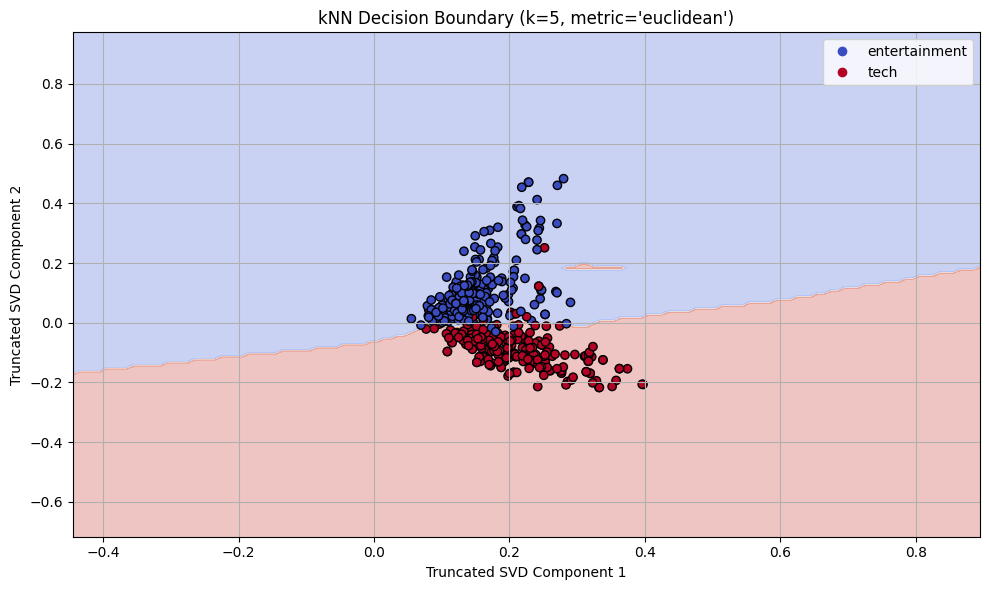

In [27]:
# Plotting the decision surface
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_encoded, cmap=plt.cm.coolwarm, edgecolor='k')
plt.title(f"kNN Decision Boundary (k={k}, metric='euclidean')")
plt.xlabel("Truncated SVD Component 1")
plt.ylabel("Truncated SVD Component 2")

# Fix legend
handles, _ = scatter.legend_elements()
plt.legend(handles=handles, labels=list(label_encoder.classes_))

plt.grid(True)
plt.tight_layout()
plt.show()


### (b) k-Nearest Neighbors Classifier [1 pt]
* Vectorized using TF-IDF and reduced dimensions via Truncated SVD.

* Trained a kNN model with k=5 and Euclidean distance.

* Plotted the 2D decision boundary surface.

* Explained how k and distance metric impact the model.

In [28]:
# Split the reduced 2D data
X_train_2d, X_test_2d, y_train_enc, y_test_enc = train_test_split(X_2d, y_encoded, test_size=0.2, random_state=42)

# Train kNN on 2D data
knn_2d = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_2d.fit(X_train_2d, y_train_enc)

# Predict
y_pred_2d = knn_2d.predict(X_test_2d)

# Accuracy
accuracy_2d = accuracy_score(y_test_enc, y_pred_2d)

# Optional: Full classification report
report_2d = classification_report(y_test_enc, y_pred_2d, target_names=label_encoder.classes_)

# Show results
print("kNN Accuracy (2D SVD-reduced data):", accuracy_2d)
print("\nClassification Report:\n", report_2d)


kNN Accuracy (2D SVD-reduced data): 0.9186046511627907

Classification Report:
                precision    recall  f1-score   support

entertainment       0.90      0.92      0.91        38
         tech       0.94      0.92      0.93        48

     accuracy                           0.92        86
    macro avg       0.92      0.92      0.92        86
 weighted avg       0.92      0.92      0.92        86

